In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir("../")

In [3]:
from ease_recommender import *
from npmi_recommender import *

import pickle as p

In [4]:
def create_mat(row, col, bool_to_int=True):
    # bool_to_int won't count duplicates in the same row, creates a different weighting basically
    if bool_to_int:
        data = np.ones_like(row, dtype=bool)
        return csr_matrix((data, (row, col))).astype(np.int64)
    else:
        data = np.ones_like(row, dtype=np.int64)
        return csr_matrix((data, (row, col)))

def check_if_all_terms_in_str(q, terms):
    for term in terms:
        if term not in q:
            return False

    return True

def get_cat2idx(category_type, D):
    if category_type == "track":
        return D["track2idx"]
    elif category_type == "album":
        return D["album2idx"]
    elif category_type == "artist":
        return D["artist2idx"]
    else:
        raise NotImplementedError

def find_match_using_terms(terms, cat2idx):
    matches = []
    for name in cat2idx.keys():
        if check_if_all_terms_in_str(name, terms):
            matches.append(name)

    if len(matches) > 1:
        raise Exception("Multiple matches found, filter down to a single match", matches)

    return matches[0]

In [5]:
print("loading cache data...")
D = p.load(open("cached_data/spotify_preprocessed.p", "rb"))

print("building csr matrices...")

# TODO: finish implementing track and album level recommendations

# track_mat = create_mat(D["playlist_indices"], D["track_indices"])
# album_mat = create_mat(D["playlist_indices"], D["album_indices"])
artist_mat = create_mat(D["playlist_indices"], D["artist_indices"])

print("done")

loading cache data...
building csr matrices...
done


In [6]:
cat2idx = get_cat2idx("artist", D)
idx2cat = {v:k for k, v in cat2idx.items()}

In [7]:
# use two items that you believe are similar to optimize the value of lambda_

a_name = find_match_using_terms(["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"], cat2idx)
# a_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)

a = cat2idx[a_name]
print(f"{a_name=}")
print(f"Num Rows: {artist_mat[:, a].sum()}")

# a = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]

# b = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]
# b = cat2idx[find_match_using_terms(["Bon Iver", "4LEiUm1SRbFMgfqnQTwUbQ"], cat2idx)]
# b = cat2idx[find_match_using_terms(["SOHN"], cat2idx)]

# b_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)
b_name = find_match_using_terms(["Highas"], cat2idx)
b = cat2idx[b_name]
print(f"{b_name=}")
print(f"Num Rows: {artist_mat[:, b].sum()}")

a_name='Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)'
Num Rows: 1981
b_name='Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)'
Num Rows: 412


In [8]:
import numpy as np
from scipy import sparse

def calculate_pmi_matrix(co_counts, alpha=1.0):
    """
    Calculates Alpha-Smoothed PMI for the entire co-occurrence matrix.
    Only computes values for observed entries (non-zeros) to maintain sparsity.
    
    Formula:
    PMI(x,y) = log( (C_xy + alpha) * N_smoothed / (S_x * S_y) )
             = log(C_xy + alpha) + log(N_smoothed) - log(S_x) - log(S_y)
    
    Args:
        co_counts: (n_items, n_items) scipy.sparse matrix (Counts of x, y).
        alpha: Smoothing parameter.
        
    Returns:
        pmi_matrix: (n_items, n_items) scipy.sparse matrix containing PMI values.
    """
    # Ensure we work with a COO matrix to easily access .row, .col, and .data
    # This is a cheap conversion if it's already CSR/CSC
    co_counts_coo = co_counts.tocoo()
    
    n_items = co_counts_coo.shape[0]
    
    # 1. Global Constants
    # Total sum of all counts in the matrix
    N_raw = co_counts_coo.sum()
    
    # Smoothed Normalization Factor: N + alpha * V^2
    N_smoothed = N_raw + (alpha * (n_items ** 2))
    
    # 2. Calculate Smoothed Marginals (S_x and S_y)
    # Row sums gives us C_x (raw marginal counts)
    # We flatten it to a dense 1D array for easy lookup
    C_marginal = np.array(co_counts_coo.sum(axis=1)).flatten()
    
    # Apply smoothing to marginals: C_x + alpha * V
    S_marginal = C_marginal + (alpha * n_items)
    
    # 3. Vectorized PMI Calculation on Non-Zero Elements
    # We operate directly on the 'data' array of the sparse matrix.
    
    # rows and cols indices for every non-zero entry
    rows = co_counts_coo.row
    cols = co_counts_coo.col
    
    # Data is C_xy
    C_xy = co_counts_coo.data
    
    # Look up the marginals for every interaction
    # If interaction is (item 5, item 99), we grab S_marginal[5] and S_marginal[99]
    Sx_vals = S_marginal[rows]
    Sy_vals = S_marginal[cols]
    
    # Apply the Log-PMI formula decomposed:
    # log(C_xy + alpha) + log(N_smoothed) - log(Sx) - log(Sy)
    
    term1 = np.log(C_xy + alpha)
    term2 = np.log(N_smoothed)
    term3 = np.log(Sx_vals)
    term4 = np.log(Sy_vals)
    
    pmi_data = term1 + term2 - term3 - term4
    
    # 4. Reconstruct Sparse Matrix
    # We create a new CSR matrix with the calculated PMI values
    pmi_matrix = sparse.csr_matrix(
        (pmi_data, (rows, cols)), 
        shape=co_counts_coo.shape
    )
    
    return pmi_matrix

In [9]:
mat = artist_mat
mat = csr_array(mat)

In [10]:
mat.shape

(1000000, 295860)

In [11]:
X = mat.T @ mat

In [12]:
X.shape

(295860, 295860)

In [13]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0, normalize=False):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [14]:
alpha = .1 * .85

In [15]:
sppmi = sparse_laplace_sppmi(X, alpha=alpha)

In [16]:
# X_coo = X.tocoo()

# row_indices = X_coo.row
# col_indices = X_coo.col

# X2 = csr_array((X_coo.data + alpha, (row_indices, col_indices)), shape=X.shape)

In [17]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [18]:
np.argsort(-sppmi[:, a].toarray()).tolist().index(b)

12

In [19]:
np.argsort(-sppmi[:, b].toarray()).tolist().index(a)

10

In [20]:
top_k = 20

In [21]:
similarity_scores = sppmi[:, a].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Matthew And The Atlas (spotify:artist:0lSENl3bteP8p2NbiSP7RM)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Axel Floven

In [22]:
similarity_scores = sppmi[:, b].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)',
 'Oh Pep! (

In [23]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=True)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5


In [24]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [25]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [26]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [161]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi_alt(X, i, p_x, N, alpha, normalize=False):
    x = X[i, :].toarray() + alpha
    
#     N = X.sum() + X.shape[0] * alpha + X.shape[1] * alpha
#     N = N + X.shape[0] * alpha + X.shape[1] * alpha
    
#     p_x = X.sum(axis=0) + X.shape[0] * alpha
    p_x = p_x + X.shape[0] * alpha
    
    N = p_x.sum()
    
    p_x = p_x / N
    p_xy = x / N
    
    assert np.isclose(p_x.sum(), 1)
    assert np.isclose(p_xy.sum(), p_x[i])
    
    pmi = p_xy / (p_x[i] * p_x)
    
    if normalize:
        return pmi / -np.log2(p_xy)
    else:
        return pmi

In [162]:
p_x = X.sum(axis=0)
N = p_x.sum()

In [165]:
alpha = .1 * .85
normalize = False

metric = (np.argsort(-sparse_laplace_sppmi_alt(X, a, p_x, N, alpha, normalize)).tolist().index(b) + 
          np.argsort(-sparse_laplace_sppmi_alt(X, b, p_x, N, alpha, normalize)).tolist().index(a))/2
metric

11.0

In [167]:
%%time

alpha = .1 * .8
normalize = True

metric = (np.argsort(-sparse_laplace_sppmi_alt(X, a, p_x, N, alpha, normalize)).tolist().index(b) + 
          np.argsort(-sparse_laplace_sppmi_alt(X, b, p_x, N, alpha, normalize)).tolist().index(a))/2
metric

CPU times: total: 812 ms
Wall time: 851 ms


11.5

In [169]:
%%time

alpha = .1 * .8

sppmi = sparse_laplace_sppmi(X, alpha=alpha, normalize=True)

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

CPU times: total: 25.2 s
Wall time: 26 s


19.5

In [59]:
np.argsort(-scores).tolist().index(a)

12

In [ ]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [23]:
def add_sparse_constant(X, alpha):
    X_coo = X.tocoo()

    row_indices = X_coo.row
    col_indices = X_coo.col

    X2 = csr_array((X_coo.data + alpha, (row_indices, col_indices)), shape=X.shape)
    
    return X2

In [48]:
from ipdb import set_trace

In [49]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi_alt(X, alpha=1.0, normalize=False):
    X = add_sparse_constant(X, alpha)
    
    N = X.sum()
    
    P_x = X.sum(axis=0) / N
#     P_y = X.sum(axis=1) / N
    
#     assert np.allclose(P_x, P_y)
    
    P_y = P_x
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
        
    P_xy = np.array(X.data) / N
    
    set_trace()
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [50]:
alpha

0.085

In [45]:
# v1 = X.sum()

# v2 = add_sparse_constant(X, 1).sum()

# X.nnz

# v2 - v1

In [51]:
sppmi = sparse_laplace_sppmi_alt(X, alpha)

> c:\users\johns\appdata\local\temp\ipykernel_10088\3408885922.py(24)sparse_laplace_sppmi_alt()

ipdb> X
<Compressed Sparse Row sparse array of dtype 'float64'
	with 244376304 stored elements and shape (295860, 295860)>
ipdb> X.eliminate_zeros()
ipdb> X
<Compressed Sparse Row sparse array of dtype 'float64'
	with 244376304 stored elements and shape (295860, 295860)>
ipdb> P_xy
array([9.37481183e-06, 2.53631616e-06, 4.61541310e-06, ...,
       4.54252958e-10, 4.54252958e-10, 4.54252958e-10], shape=(244376304,))
ipdb> P_x
array([6.33405618e-04, 1.08530877e-03, 2.36986468e-03, ...,
       1.36275887e-09, 1.36275887e-09, 1.90786242e-08], shape=(295860,))
ipdb> row_indices
*** NameError: name 'row_indices' is not defined
ipdb> n
> c:\users\johns\appdata\local\temp\ipykernel_10088\3408885922.py(26)sparse_laplace_sppmi_alt()

ipdb> exit


In [37]:
metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

2170.0

In [40]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/2, normalize=True)

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

14.0

In [41]:
similarity_scores = sppmi[:, a].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Ásgeir Traus

In [42]:
similarity_scores = sppmi[:, b].toarray()
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)',
 'Farao (spotify:artist:6XIX2G6ZGiVQgMr6SSTMFu)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Oh Pep! (spotify:artist:3L9rqEIsNSaOcx2QIstn7v)',
 'Amason 

In [117]:
def pmi(mat, alpha, i):
    mat2 = add_sparse_constant(mat, alpha)

    py = mat2.sum(axis=0) / (mat2.shape[0] * (alpha + 1))
    pxy = ((mat2[:, i:i+1] * mat2).sum(axis=0)) / (mat2.shape[0] * (alpha + 1))
    px = py[i]

    pmi = pxy / (px * py)
    # pmi = np.log2(pxy) - (np.log2(px) + np.log2(py))
    
    return pmi

In [118]:
# alpha = 1

# mat.shape[0] + mat.shape[0] * alpha

# (mat[:, 0].toarray() + 1) / (mat.shape[0] + mat.shape[0] * alpha)

In [121]:
alpha = 2

metric = (np.argsort(-pmi(mat, alpha, a)).tolist().index(b) + np.argsort(-pmi(mat, alpha, b)).tolist().index(a))/2
metric

2132.0

In [133]:
alpha = 1

mat2 = add_sparse_constant(mat, alpha)
mat2.sum(axis=0) / (mat2.shape[0] * (alpha + 1))

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [136]:
mat2.sum(axis=0)

array([ 44784,  81548, 194936, ...,      2,      2,      2],
      shape=(295860,))

In [79]:
pmi(mat, 2, a)

array([0.20289211, 0.18570494, 0.5230881 , ..., 0.        , 0.        ,
       0.        ], shape=(295860,))

In [ ]:
# npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

In [ ]:
# py = mat.mean(axis=0)
py = mat.sum(axis=0) / N_smoothd
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

In [ ]:
sppmi = sparse_laplace_sppmi(X, alpha=.1*4)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [55]:
sppmi = sparse_laplace_sppmi(X, alpha=.2)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

27.0

In [60]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * 1.1)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

14.0

In [63]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .95)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [59]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .9)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [64]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .85)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.0

In [61]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .8)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [62]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .7)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

11.5

In [ ]:
sppmi = sparse_laplace_sppmi(X, alpha=.1 * .7)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

In [57]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/2)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

18.0

In [58]:
sppmi = sparse_laplace_sppmi(X, alpha=.1/4)

# sppmi = X

metric = (np.argsort(-sppmi[:, a].toarray()).tolist().index(b) + np.argsort(-sppmi[:, b].toarray()).tolist().index(a))/2
metric

70.0

In [50]:
import numpy as np
from scipy import sparse

def get_sppmi_row(X, row_idx, alpha=1.0):
    """
    Calculates a single row of the Laplace Smoothed PPMI matrix efficiently.
    Returns a dense numpy array for the target row index.
    """
    # Ensure X is indexable. 
    # (Even if X is coo_array, we can often slice it in new SciPy, 
    # but converting the source to CSR is generally faster for row access).
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    rows, cols = X.shape
    
    # 1. Global Statistics
    N_raw = X.sum()
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # 2. Marginals
    # Sum of all columns (flattened to 1D array)
    col_sums = np.array(X.sum(axis=0)).flatten()
    
    # Get the specific row and FORCE it to be CSR so .indices works
    target_row_sparse = X[row_idx].tocsr()
    row_sum = target_row_sparse.sum()
    
    # Calculate Smoothed Probabilities
    # P(y) is a vector (shape: cols,)
    P_y = (col_sums + (alpha * rows)) / N_smoothed
    
    # P(x) is a scalar (for this specific row)
    P_x = (row_sum + (alpha * cols)) / N_smoothed
    
    # 3. Base Calculation: The "Background" (Zero Count) Case
    # Calculate PMI assuming count=0 (only alpha) for the whole row
    P_xy_base = alpha / N_smoothed
    denominator = P_x * P_y
    
    # Initialize result vector with the base values
    row_ratios = P_xy_base / denominator

    # 4. Update the "Foreground": The Non-Zero Data
    # Now .indices will definitely work because we enforced .tocsr() above
    nz_col_indices = target_row_sparse.indices
    nz_raw_counts = target_row_sparse.data
    
    # Calculate P(x,y) using real counts
    P_xy_real = (nz_raw_counts + alpha) / N_smoothed
    
    # Update only the specific indices
    row_ratios[nz_col_indices] = P_xy_real / denominator[nz_col_indices]
    
    # 5. Compute Log
    pmi_row = np.log2(row_ratios)
    
    return pmi_row

In [51]:
row = get_sppmi_row(X, a, .1)

In [52]:
assert (sppmi[0, :].toarray() == sppmi[:, 0].toarray()).all()

In [54]:
row

array([-1.34328819, -1.37872428,  0.24586819, ..., -2.14993536,
       -2.14993536, -2.15183566], shape=(295860,))

In [53]:
np.allclose(sppmi[0, :].toarray(), row)

False

In [46]:
sppmi[0, :].toarray()

array([6.71543835, 4.06333962, 3.80849313, ..., 0.        , 0.        ,
       0.        ], shape=(295860,))

In [47]:
row

array([-1.34328813, -1.37872425,  0.24586817, ...,  0.        ,
        0.        ,  0.        ], shape=(295860,))

In [35]:
row

array([-1.34328813, -1.37872425,  0.24586817, ...,  0.        ,
        0.        ,  0.        ], shape=(295860,))

In [ ]:
np.ar

In [ ]:
X = mat @ mat.T

In [ ]:
X.shape

In [ ]:
target_indices, pmi_values = calculate_sparse_pmi_for_item(mat, i, alpha=1.0)

In [8]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [9]:
i = a
j = b

In [12]:
# eps = 1e-14
eps = 0

In [14]:
mat.shape

(1000000, 295860)

In [24]:
alpha = 1

mat = artist_mat
mat = csr_array(mat)

rows = mat.shape[-1]
cols = rows

N_raw = mat.shape[0]
rows, cols = mat.shape

N_smoothed = N_raw + (alpha * rows * cols)

# py = mat.mean(axis=0)
py = mat.sum(axis=0) / N_smoothd
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

In [22]:
mat.sum(axis=0) / mat.shape[0]

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [23]:
mat.mean(axis=0)

array([2.2392e-02, 4.0774e-02, 9.7468e-02, ..., 1.0000e-06, 1.0000e-06,
       1.0000e-06], shape=(295860,))

In [18]:
pxy.shape

(295860,)

In [17]:
px.shape

()

In [15]:
pxy.shape

(295860,)

In [ ]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

In [25]:
import numpy as np

def calculate_smoothed_pmi_item(mat, i, alpha=1.0):
    """
    Calculates PMI for item i against all other items using additive (alpha) smoothing.
    
    Definitions:
    - N: Total number of co-occurrence pairs observed across all users.
    - C(x, y): Number of times x and y co-occur (summing over users).
    - C(y): Total number of co-occurrences involving y.
    
    Args:
        mat: (n_users, n_items) numpy array (binary or counts)
        i: Index of the target item
        alpha: Smoothing parameter (Laplace smoothing)
    """
    n_users, n_items = mat.shape
    
    # 1. Pre-calculate Basket Sizes (Row Sums)
    # This is needed to weight the marginals correctly.
    # If a user bought 3 items, they contribute 3 pairs for each item they bought.
    # shape: (n_users,)
    user_basket_sizes = mat.sum(axis=1)
    
    # 2. Calculate Total Number of Co-occurrences (N)
    # The sum of the entire co-occurrence matrix (without materializing it).
    # It is equal to the sum of squared basket sizes.
    # N_raw = sum( (sum(row))^2 )
    N_raw = np.sum(user_basket_sizes ** 2)
    
    # 3. Calculate Smoothed Normalization Constant
    # Since we add alpha to every cell in the (n_items x n_items) co-occurrence matrix:
    N_smoothed = N_raw + (alpha * (n_items ** 2))
    
    # 4. Calculate Raw Co-occurrence Counts for Item i (Vector C_xy)
    # shape: (n_items,)
    # We multiply column i by the matrix to get interactions, then sum over users.
    C_xy = (mat[:, i:i+1] * mat).sum(axis=0)
    
    # 5. Calculate Raw Marginal Counts (Vector C_y)
    # The marginal count of an item y in co-occurrence space is sum(matrix * basket_sizes).
    # Conceptually: mat.T @ user_basket_sizes
    # This weights popular items by the activity of the users who bought them.
    # shape: (n_items,)
    C_y = np.dot(mat.T, user_basket_sizes)
    
    # 6. Calculate Raw Marginal Count for Target Item i (Scalar C_x)
    C_x = C_y[i]
    
    # 7. Apply Smoothing to Probabilities
    # P(x, y) = (Count(x, y) + alpha) / N_smoothed
    pxy = (C_xy + alpha) / N_smoothed
    
    # P(y) = (Count(y) + alpha * n_items) / N_smoothed
    # Note: We add alpha * n_items because the marginal is the sum of a row of smoothed joints.
    py = (C_y + (alpha * n_items)) / N_smoothed
    
    # P(x) = (Count(x) + alpha * n_items) / N_smoothed
    px = (C_x + (alpha * n_items)) / N_smoothed
    
    # 8. Calculate PMI
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    pmi_vector = np.log(pxy / (px * py))
    
    return pmi_vector

In [ ]:
calculate_smoothed_pmi_item(mat, i)

In [10]:
o = 3.2e-8

metric(a, b, o)

17.5

In [16]:
def metric(i, j, o, lambda_=0, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
    pxy_scaled = pxy**lambda_
        
    score = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)
#     score = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

    score *= pxy_scaled

    if call_again:
        return (metric(j, i, o, lambda_, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [41]:
metric(a, b, 1e-9, lambda_=0.13408607326731756)

41.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
lambda_

np.float64(0.13408607326731756)

In [ ]:
pxy_scaled = pxy**lambda_
        
    return (npmi * pxy_scaled) / pxy_scaled.max()

In [29]:
# def print_and_return(x, y=1):
#     print(x/y)
#     return x

# res = minimize_scalar(lambda o: print_and_return(2*metric(a, b, abs(o) * 1e-8) + abs(o)*1e-8, 2))
# res

In [30]:
lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, a, b, fast_approximation=False)

lambda_: 1000000
error: 339.0
lambda_: 100000.0
error: 157.0
lambda_: 10000.0
error: 38.0
lambda_: 1000.0
error: 5.0
lambda_: 100.0
error: 3.0
lambda_: 10.0
error: 3.5
lambda_: 10.0
error: 3.5
lambda_: 100.0
error: 3.0
lambda_: 1000.0
error: 5.0
lambda_: 443.7694
error: 3.5


KeyboardInterrupt: 

In [31]:
lambda_ = 100

In [32]:
# check final error for EASE
a_to_b_error_metric(artist_mat, a, b, lambda_)

lambda_: 100
error: 3.0


3.0

In [34]:
top_k = 20

In [35]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, a, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Snakadaktal (spotify:artist:0SdEkx5Ai2gl0W7pnhlsfy)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Seoul (spotify:artist:3e69LorE0YSsEaYY6x9XuG)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Caroline Smith (spotify:artist:47blM5Op3BJODxUJImwdYE)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Ásgeir Trausti (spotif

In [36]:
# using EASE

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [42]:
# using EASE

similarity_scores_a = calculate_ease_for_item_cg(artist_mat, a, lambda_) 
similarity_scores_b = calculate_ease_for_item_cg(artist_mat, b, lambda_) 

similarity_scores = similarity_scores_a + similarity_scores_b 
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Júníus Meyvant (spotify:artist:5IL5awl9gUcb2ez9IgmW26)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'San Fermin (spotify:artist:7fSnislKgW9Mz0YIqWQmGt)',
 'Only Real (spotify:artist:5cyHu7tidauRJ9UawaPwG5)',
 'Big Scary (spotify:artist:4mLYW48jy9Pwv6KpT74Evf)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Neulore (spotify:artist:6SLbaDa56f1CZlUNuF0gk3)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones

In [43]:
lambda_

100

In [66]:
eps = 1e-14
# eps = 0

lambda_ = .09

i, j = a, b
# i, j = b, a

mat = artist_mat
mat = csr_array(mat)

# py = mat.mean(axis=0)
# pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
# px = py[i]

py = mat.mean(axis=0)
pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
px = py[i]

npmi = (np.log2(pxy + o) - (np.log2(px + np.sqrt(o)) + np.log2(py + np.sqrt(o)))) / -np.log2(pxy + o)

# o = .25
# npmi = (np.log2(pxy + o**2)) - (np.log2(px + o) + np.log2(py + o)) / -np.log2(pxy + o**2)

# score = pxy / np.where(px > py, px, py)
# score = pxy / np.where(px < py, px, py)
# score = pxy / (px * py)
# score = pxy / np.sqrt((px * py))
# score = pxy / (px + py)
# score = pxy / ((px + py)/2)

# score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
score = npmi

top_k_matches = [idx2cat[idx] for idx in np.argsort(-score)[:top_k].tolist()]

np.argsort(-score).tolist().index(j)

26

In [67]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)',
 'PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)',
 'S. Carey (spotify:artist:2LSJrlndCuTpdEluvYHc2E)',
 'Nick Mulvey (spotify:artist:3x8FbPjh2Qz55XMdE2Yalj)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Little May (spotify:artist:0TjAAwE04BeoSeOpJIakYH)',
 'Th

In [38]:
def make_cache(i, j):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]

    npmi = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)
    
    return (npmi, pxy)

  0%|          | 0/100 [00:00<?, ?it/s]

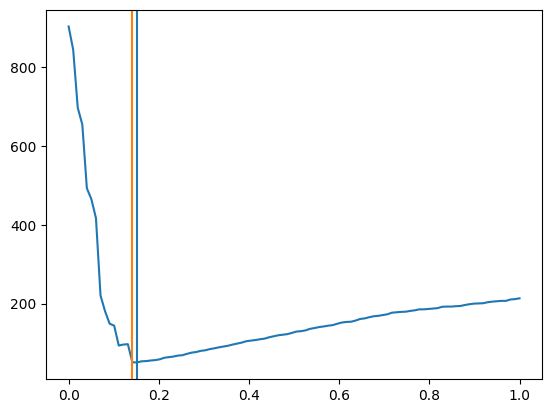

In [39]:
from tqdm.auto import tqdm

eps = 1e-14

cache_a = make_cache(a, b)
cache_b = make_cache(b, a)

lambdas = np.linspace(0, 1, 100)

rankings_a = []
rankings_b = []
rankings_combined = []
for lambda_ in tqdm(lambdas):
#     score = npmi_batch_popularity_weighted(mat, i, lambda_, cache=(npmi, pxy), eps=eps)
#     rankings.append(np.argsort(-score).tolist().index(j))

    score_a = npmi_batch_popularity_weighted(mat, a, lambda_, cache=cache_a, eps=eps)
    score_b = npmi_batch_popularity_weighted(mat, b, lambda_, cache=cache_b, eps=eps)
    
    rankings_a.append(np.argsort(-score_a).tolist().index(b))
    rankings_b.append(np.argsort(-score_b).tolist().index(a))
    rankings_combined.append((rankings_a[-1] + rankings_b[-1])/2)

# min(np.diff(rankings))

import matplotlib.pyplot as plt

rankings = rankings_combined

plt.plot(lambdas, rankings);
plt.axvline(lambdas[np.argmin(rankings)]);
plt.axvline(.14, c="tab:orange");

In [32]:
lambdas[np.argmin(rankings)]

np.float64(0.15151515151515152)

In [33]:
min(rankings)

50.5

In [34]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [35]:
a_to_b_error_metric_npmi_pop_weighted(artist_mat, a, b, lambda_)

lambda_: 0.13408607326731756
error: 47.5


47.5

In [396]:
def metric(i, j, o, call_again = True, eps = 1e-14):
    mat = artist_mat
    mat = csr_array(mat)

    py = mat.mean(axis=0)
    pxy = (mat[:, i:i+1] * mat).mean(axis=0) + eps
    px = py[i]
    
#     py = (py * o) + (.5 * (1 - o))
#     px = (px * o) + (.5 * (1 - o))
#     pxy = (pxy * o) + (.5**2 * (1 - o))
#     pxy = (pxy * o) + ((px * py) * (1 - o))

#     px = py = np.where(px > py, px, py)
    px = py = (px + py)/2
#     px = py = px + py

#     px = np.where(px > py, px, py)
#     px = (px + py)/2
#     px = px + py
    
#     py = np.where(px > py, px, py)
#     py = (px + py)/2
#     py = px + py

#     py = np.where(px < py, px, py)
    score = (np.log2(pxy) - (np.log2(px) + np.log2(py))) / -np.log2(pxy)

    if call_again:
        return (metric(j, i, o, call_again = False, eps=eps) + np.argsort(-score).tolist().index(j))/2
    else:
        return np.argsort(-score).tolist().index(j)

In [397]:
metric(a, b, .6)

98.5

In [267]:
metric(a, b, .11)

105.0

In [246]:
top_k_matches

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Quiet Arrows (spotify:artist:7KRnRH8bRvoX4ebQwHw2EI)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'Vök (spotify:artist:7oDTyDfeA2JE2jUZztkBj8)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)',
 'The Careful Ones (spotify:artist:1DdAoWvETBUklcJCOISZx1)',
 'This, the Silent War (spotify:artist:3156bBfcG5gFSWrftU8gaR)',
 'The Acid (spotify:artist:0bRtSoJSpQdnbB3dWrWprR)',
 'Josh Jenkins (spotify:artist:20nyUQUh2kYdqOauF3y3Pu)',
 'Choir Of Young Believers (spotify:artist:4aXPrNXYJLziXeH7Obkea7)',
 'Samaris (spotify:artist:1Xl5hsislt88ijOD3EZsOY)',
 'Mimicking Birds (spotify:artist:5PifaykkaJRJlWbUz3H0od)',
 'Adurn (spotify:artist:4hDzPWJ7vNSD2wCEF49w8r)',
 'Joe Banfi (spotify:artist:5XuI2JDHF

In [37]:
lambda_ = optimize_lambda_using_a_to_b_matching_npmi(artist_mat, a, b)

lambda_: 0.0
error: 1806.0
lambda_: 1.0
error: 426
lambda_: 2.6180339999999998
error: 625
lambda_: 1.6180339748439998
error: 518
lambda_: 0.618034
error: 305.618034
lambda_: 0.381966025156
error: 198.381966025156
lambda_: 0.23606799039126328
error: 133.23606799039126
lambda_: 0.145898044373474
error: 101.14589804437347
lambda_: 0.09016995195631564
error: 355.09016995195634
lambda_: 0.1803398979741049
error: 107.18033989797411
lambda_: 0.136098829051948
error: 99.13609882905195
lambda_: 0.11855555958323769
error: 189.11855555958323
lambda_: 0.1293978965860626
error: 189.12939789658606
lambda_: 0.13984179613145
error: 101.13984179613145
lambda_: 0.13353930068168363
error: 193.1335393006817
lambda_: 0.13752851521543707
error: 99.13752851521544
lambda_: 0.13681150750011398
error: 99.13681150750011
lambda_: 0.1351211762384716
error: 96.13512117623847
lambda_: 0.13451695355954754
error: 95.13451695355955
lambda_: 0.13389245935456162
error: 193.13389245935457
lambda_: 0.1342784180060459
error

In [33]:
top_k = 20

In [34]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, a, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Ganic (spotify:artist:2qT4UNxM0aOz52gpSXuooT)',
 'Feitn Fra Kolbotn (spotify:artist:5pTo5SvSAVsfJ9vbVwQyUt)',
 'ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Surferosa (spotify:artist:5WUYimkWakv41ZVVIq3BDr)',
 'Mikkel Øwre (spotify:artist:1kNHqkERzDBPrzdK9DogGQ)',
 'Pieces of Juno (spotify:artist:1k88AWvVVqKbz6C0kK624d)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'A-Laget (spotify:artist:2eJz0fbC9ZqBL3mGWPBvI5)',
 'The White Birch (spotify:artist:3pDnwHQUEXbkNX3cvidKpG)',
 'Carl Louis (spotify:artist:5LY4Rzduoz5b0qZdV3rHwK)',
 'Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Morten Myklebust (spotify:artist:7zFc6IlzgDwyXoj

In [35]:
# using normalized pointwise mutual information (popularity weighted)

similarity_scores = npmi_batch_popularity_weighted(artist_mat, b, lambda_)

top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)',
 'Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)',
 'José González (spotify:artist:6xrCU6zdcSTsG2hLrojpmI)',
 'Sylvan Esso (spotify:artist:39vA9YljbnOApXKniLWBZv)',
 'SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)',
 'Ben Howard (spotify:artist:5schNIzWdI9gJ1QRK8SBnc)',
 "Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)",
 'Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)',
 'Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)',
 'London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)',
 'Chet Faker (spotify:artist:2Q0MyH5YMI5HPQjFjlq5g3)',
 'Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)',
 'James Blake (spotify:artist:53KwLdlmrlCelAZMaLVZqU)',
 'The Paper Kites (spotify:artist:79hrYiudVcFyyxyJW0ipTy)',
 'Matt Corby (spotify:artist:7CIW23FQUXPc1zebnO1TDG)',
 'Low Volts (spotify:artist:3PxUwSSsVaW0XyBiRJF2oS)',
 'Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)',
 'Panama (spotify:artist:3W9UldYu0xJcaOA